In [3]:
# ================================================================
# 1. IMPORTS & GLOBAL SETTINGS
# ================================================================
import mysql.connector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
import os
from dotenv import load_dotenv
import mysql.connector

load_dotenv()

print("Starting connection...")

connection = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

print("Connected successfully!")

,user_id,org_id,role
0,U0001,ORG018,Employee
1,U0002,ORG007,Analyst
2,U0003,ORG062,Employee
3,U0004,ORG071,Admin
4,U0005,ORG092,Analyst
...,...,...,...
1495,U1496,ORG018,Employee
1496,U1497,ORG096,Employee
1497,U1498,ORG100,Employee
1498,U1499,ORG035,Analyst


## 1. Data Loading & Overview

In [ ]:
table_names = [
    "organizations",
    "systems",
    "users",
    "login_logs",
    "network_events",
    "security_incidents",
    "incident_systems",
]

# Query each table directly from your active connection
tables = {
    table: pd.read_sql(f"SELECT * FROM {table}", connection)
    for table in table_names
}

# Unpack into individual variables if needed
organizations = tables["organizations"]
systems = tables["systems"]
users = tables["users"]
login_logs = tables["login_logs"]
network_events = tables["network_events"]
security_incidents = tables["security_incidents"]
incident_systems = tables["incident_systems"]

for name, tdf in tables.items():
    print(f"{name:20s} -> rows: {tdf.shape[0]:>7,}   columns: {tdf.shape[1]}")

organizations        -> rows:     120   columns: 3
systems              -> rows:     600   columns: 4
users                -> rows:   1,500   columns: 3
login_logs           -> rows:   6,000   columns: 5
network_events       -> rows:   5,000   columns: 5
security_incidents   -> rows:     500   columns: 5
incident_systems     -> rows:     500   columns: 2


In [22]:
# Quick structural look at each table
for name, df in tables.items():
    print("="*70)
    print(name.upper())
    print(df.head(3))

ORGANIZATIONS
   org_id    industry country
0  ORG001     Finance     USA
1  ORG002        Tech      UK
2  ORG003  Healthcare      UK
SYSTEMS
  system_id  org_id os_type criticality
0     S0001  ORG075     Mac         Low
1     S0002  ORG080   Linux      Medium
2     S0003  ORG085     Mac        High
USERS
  user_id  org_id      role
0   U0001  ORG018  Employee
1   U0002  ORG007   Analyst
2   U0003  ORG062  Employee
LOGIN_LOGS
  login_id user_id  login_time       ip_address   status
0   L00001   U0183  2023-11-27   192.168.49.114  Success
1   L00002   U0834  2024-04-12  192.168.190.125   Failed
2   L00003   U0116  2024-02-25  192.168.132.203  Success
NETWORK_EVENTS
  event_id system_id    event_type   timestamp  severity
0   E00001     S0107         Login  2023-03-29  Critical
1   E00002     S0562         Login  2024-02-13  Critical
2   E00003     S0047  Network Scan  2023-02-19      High
SECURITY_INCIDENTS
  incident_id  org_id        incident_type discovered_date  severity
0       I0

In [23]:
# dtypes + non-null counts (core pandas introspection, like SQL DESCRIBE)
for name, df in tables.items():
    print("="*70, "\n", name)
    df.info()

 organizations
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   org_id    120 non-null    object
 1   industry  120 non-null    object
 2   country   120 non-null    object
dtypes: object(3)
memory usage: 2.9+ KB
 systems
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   system_id    600 non-null    object
 1   org_id       600 non-null    object
 2   os_type      600 non-null    object
 3   criticality  600 non-null    object
dtypes: object(4)
memory usage: 18.9+ KB
 users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  1500 non-null   object
 1   org_id   1500 non-null

## 2. Data Cleaning
Even though the tables were already loaded cleanly into SQL, we re-validate everything
in Python: missing values, duplicates, whitespace/casing issues, date parsing,
referential integrity (orphan foreign keys), and basic format checks (e.g. IP addresses).

In [24]:
# --- 2.1 Missing values ---
print("Missing values per table:\n")
for name, df in tables.items():
    nulls = df.isnull().sum()
    if nulls.sum() == 0:
        print(f"{name:20s}: no missing values")
    else:
        print(f"{name:20s}:\n{nulls[nulls>0]}")

Missing values per table:

organizations       : no missing values
systems             : no missing values
users               : no missing values
login_logs          : no missing values
network_events      : no missing values
security_incidents  : no missing values
incident_systems    : no missing values


In [25]:
# --- 2.2 Duplicate rows / duplicate primary keys ---
pk_cols = {
    "organizations": "org_id", "systems": "system_id", "users": "user_id",
    "login_logs": "login_id", "network_events": "event_id",
    "security_incidents": "incident_id"
}
for name, col in pk_cols.items():
    df = tables[name]
    dup_rows = df.duplicated().sum()
    dup_keys = df[col].duplicated().sum()
    print(f"{name:20s}: duplicate rows={dup_rows}, duplicate {col}={dup_keys}")

print("incident_systems  : duplicate (incident_id, system_id) pairs =",
      incident_systems.duplicated(subset=["incident_id", "system_id"]).sum())

organizations       : duplicate rows=0, duplicate org_id=0
systems             : duplicate rows=0, duplicate system_id=0
users               : duplicate rows=0, duplicate user_id=0
login_logs          : duplicate rows=0, duplicate login_id=0
network_events      : duplicate rows=0, duplicate event_id=0
security_incidents  : duplicate rows=0, duplicate incident_id=0
incident_systems  : duplicate (incident_id, system_id) pairs = 0


In [26]:
# --- 2.3 Whitespace / casing consistency in categorical text columns ---
cat_cols = {
    "organizations": ["industry", "country"],
    "systems": ["os_type", "criticality"],
    "users": ["role"],
    "login_logs": ["status"],
    "network_events": ["event_type", "severity"],
    "security_incidents": ["incident_type", "severity"],
}
for tname, cols in cat_cols.items():
    for c in cols:
        raw = tables[tname][c]
        stripped_diff = (raw.str.strip() != raw).sum()
        case_variants = raw.str.lower().nunique() != raw.nunique()
        print(f"{tname}.{c:15s} -> categories={sorted(raw.unique())}, "
              f"leading/trailing space issues={stripped_diff}, case inconsistency={case_variants}")

organizations.industry        -> categories=['Finance', 'Healthcare', 'Retail', 'Tech'], leading/trailing space issues=0, case inconsistency=False
organizations.country         -> categories=['Canada', 'Germany', 'UK', 'USA'], leading/trailing space issues=0, case inconsistency=False
systems.os_type         -> categories=['Linux', 'Mac', 'Windows'], leading/trailing space issues=0, case inconsistency=False
systems.criticality     -> categories=['High', 'Low', 'Medium'], leading/trailing space issues=0, case inconsistency=False
users.role            -> categories=['Admin', 'Analyst', 'Employee'], leading/trailing space issues=0, case inconsistency=False
login_logs.status          -> categories=['Failed', 'Success'], leading/trailing space issues=0, case inconsistency=False
network_events.event_type      -> categories=['File Access', 'Login', 'Malware Alert', 'Network Scan'], leading/trailing space issues=0, case inconsistency=False
network_events.severity        -> categories=['Critical

In [27]:
# --- 2.4 Parse date columns explicitly ---
login_logs["login_time"] = pd.to_datetime(login_logs["login_time"])
network_events["timestamp"] = pd.to_datetime(network_events["timestamp"])
security_incidents["discovered_date"] = pd.to_datetime(security_incidents["discovered_date"])

print("login_time range      :", login_logs.login_time.min(), "->", login_logs.login_time.max())
print("network timestamp range:", network_events.timestamp.min(), "->", network_events.timestamp.max())
print("discovered_date range :", security_incidents.discovered_date.min(), "->", security_incidents.discovered_date.max())

login_time range      : 2023-01-01 00:00:00 -> 2024-05-15 00:00:00
network timestamp range: 2023-01-01 00:00:00 -> 2024-05-15 00:00:00
discovered_date range : 2023-01-01 00:00:00 -> 2024-05-15 00:00:00


In [28]:
# --- 2.5 IP address format sanity check (simple regex) ---
import re
ip_pattern = re.compile(r"^(\d{1,3}\.){3}\d{1,3}$")
bad_ips = login_logs[~login_logs.ip_address.str.match(ip_pattern)]
print("Malformed IP addresses:", len(bad_ips))

# also check each octet is 0-255
def valid_ip(ip):
    parts = ip.split(".")
    return len(parts) == 4 and all(p.isdigit() and 0 <= int(p) <= 255 for p in parts)

invalid_octets = (~login_logs.ip_address.apply(valid_ip)).sum()
print("IPs with out-of-range octets:", invalid_octets)

Malformed IP addresses: 0
IPs with out-of-range octets: 0


In [29]:
# --- 2.6 Referential integrity: orphan foreign keys ---
orphan_systems   = systems[~systems.org_id.isin(organizations.org_id)]
orphan_users     = users[~users.org_id.isin(organizations.org_id)]
orphan_logins    = login_logs[~login_logs.user_id.isin(users.user_id)]
orphan_netevents = network_events[~network_events.system_id.isin(systems.system_id)]
orphan_incidents = security_incidents[~security_incidents.org_id.isin(organizations.org_id)]
orphan_is_inc    = incident_systems[~incident_systems.incident_id.isin(security_incidents.incident_id)]
orphan_is_sys    = incident_systems[~incident_systems.system_id.isin(systems.system_id)]

print("Orphan systems (bad org_id)       :", len(orphan_systems))
print("Orphan users (bad org_id)         :", len(orphan_users))
print("Orphan login_logs (bad user_id)   :", len(orphan_logins))
print("Orphan network_events (bad sys_id):", len(orphan_netevents))
print("Orphan security_incidents (bad org):", len(orphan_incidents))
print("Orphan incident_systems->incident :", len(orphan_is_inc))
print("Orphan incident_systems->system   :", len(orphan_is_sys))

Orphan systems (bad org_id)       : 0
Orphan users (bad org_id)         : 0
Orphan login_logs (bad user_id)   : 0
Orphan network_events (bad sys_id): 0
Orphan security_incidents (bad org): 0
Orphan incident_systems->incident : 0
Orphan incident_systems->system   : 0


**Cleaning summary:** no missing values, no duplicate primary keys, no whitespace/casing
inconsistencies, all IP addresses well-formed, and zero orphan foreign keys across every
relationship. The dataset is referentially clean, so no rows need to be dropped or imputed —
we only needed to **cast the three date columns to `datetime64`** for later time-based analysis.

## 3. Feature Engineering (merges used throughout the notebook)
Most of the raw tables are just IDs + one or two categorical columns, so the interesting
numeric signal only appears once we **join across tables** and **aggregate**. We build a
few reusable, wide/merged frames here.

In [30]:
# System-level view: which org, which incidents was this system part of
systems_full = systems.merge(organizations, on="org_id", how="left")

# Network events enriched with system + org attributes
network_full = network_events.merge(systems_full, on="system_id", how="left")

# Login logs enriched with user + org attributes
users_full = users.merge(organizations, on="org_id", how="left")
login_full = login_logs.merge(users_full, on="user_id", how="left")

# Incidents enriched with org attributes
incidents_full = security_incidents.merge(organizations, on="org_id", how="left")

# Which systems were touched by which incidents, with system + incident attributes
incident_systems_full = (incident_systems
                          .merge(incidents_full, on="incident_id", how="left")
                          .merge(systems[["system_id", "os_type", "criticality"]], on="system_id", how="left"))

login_full.head()

,login_id,user_id,login_time,ip_address,status,org_id,role,industry,country
0,L00001,U0183,2023-11-27,192.168.49.114,Success,ORG106,Analyst,Finance,UK
1,L00002,U0834,2024-04-12,192.168.190.125,Failed,ORG038,Employee,Finance,UK
2,L00003,U0116,2024-02-25,192.168.132.203,Success,ORG079,Employee,Finance,USA
3,L00004,U0638,2023-02-03,192.168.182.130,Failed,ORG053,Admin,Finance,Germany
4,L00005,U1074,2023-03-11,192.168.226.146,Success,ORG111,Analyst,Healthcare,UK


In [31]:
# Org-level aggregated numeric feature table (this is our main "numeric" dataset
# for statistical / outlier / multivariate work, since raw tables are mostly categorical)
org_stats = organizations.copy()
org_stats["n_systems"]   = org_stats.org_id.map(systems.groupby("org_id").size()).fillna(0).astype(int)
org_stats["n_users"]     = org_stats.org_id.map(users.groupby("org_id").size()).fillna(0).astype(int)
org_stats["n_incidents"] = org_stats.org_id.map(security_incidents.groupby("org_id").size()).fillna(0).astype(int)
org_stats["n_critical_systems"] = org_stats.org_id.map(
    systems[systems.criticality == "High"].groupby("org_id").size()).fillna(0).astype(int)

# failed login counts joined back to org via user -> org
failed_by_user = login_full[login_full.status == "Failed"].groupby("user_id").size()
users_full["n_failed_logins"] = users_full.user_id.map(failed_by_user).fillna(0).astype(int)
org_stats["n_failed_logins"] = org_stats.org_id.map(
    users_full.groupby("org_id").n_failed_logins.sum()).fillna(0).astype(int)

org_stats["incident_rate_per_system"] = (org_stats.n_incidents / org_stats.n_systems.replace(0, np.nan)).fillna(0)
org_stats.describe(include="all")

,org_id,industry,country,n_systems,n_users,n_incidents,n_critical_systems,n_failed_logins,incident_rate_per_system
count,120,120,120,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
unique,120,4,4,NaN,NaN,NaN,NaN,NaN,NaN
top,ORG001,Finance,USA,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,33,37,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,5.000000,12.500000,4.166667,1.841667,24.666667,1.199966
std,NaN,NaN,NaN,2.264078,3.434868,2.131529,1.378075,7.609518,1.502371
min,NaN,NaN,NaN,1.000000,6.000000,0.000000,0.000000,5.000000,0.000000
25%,NaN,NaN,NaN,3.750000,10.000000,3.000000,1.000000,19.000000,0.500000
50%,NaN,NaN,NaN,5.000000,12.000000,4.000000,2.000000,24.500000,0.750000
75%,NaN,NaN,NaN,6.000000,15.000000,5.000000,3.000000,29.000000,1.333333


## 4. Univariate Analysis
Distribution of every categorical field on its own, plus the distribution of the numeric
features we engineered above (systems/users/incidents per organization).

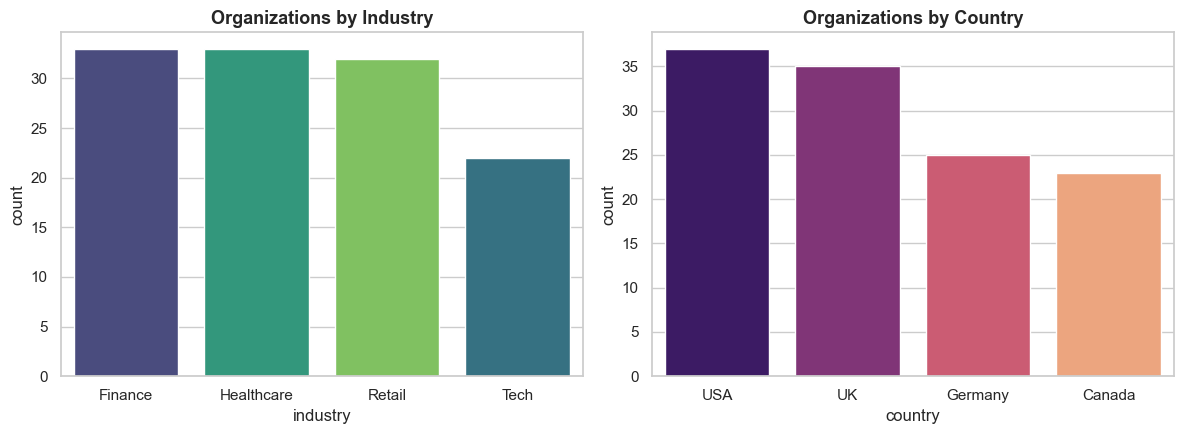

industry
Finance       27.5%
Healthcare    27.5%
Retail        26.7%
Tech          18.3%
Name: proportion, dtype: object


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=organizations, x="industry", hue="industry", legend=False,
              order=organizations.industry.value_counts().index, ax=axes[0], palette="viridis")
axes[0].set_title("Organizations by Industry")
sns.countplot(data=organizations, x="country", hue="country", legend=False,
              order=organizations.country.value_counts().index, ax=axes[1], palette="magma")
axes[1].set_title("Organizations by Country")
plt.tight_layout(); plt.show()
print(organizations.industry.value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

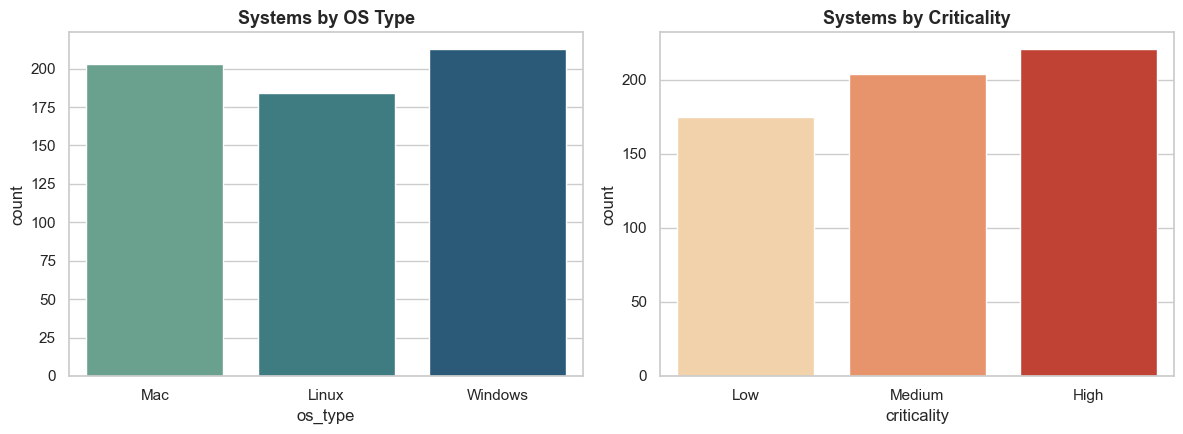

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=systems, x="os_type", hue="os_type", legend=False, ax=axes[0], palette="crest")
axes[0].set_title("Systems by OS Type")
sns.countplot(data=systems, x="criticality", hue="criticality", legend=False,
              order=["Low", "Medium", "High"], ax=axes[1], palette="OrRd")
axes[1].set_title("Systems by Criticality")
plt.tight_layout(); plt.show()

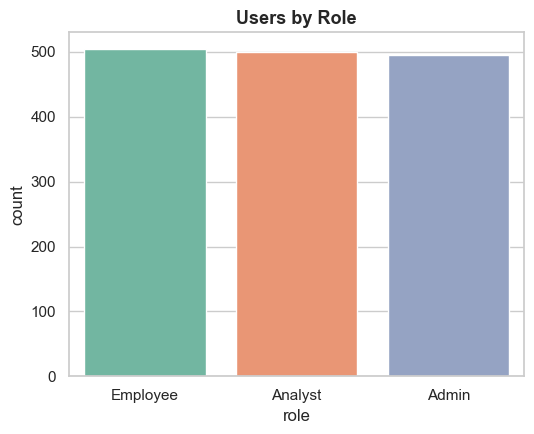

role
Employee    505
Analyst     500
Admin       495
Name: count, dtype: int64


In [35]:
plt.figure(figsize=(5.5, 4.5))
sns.countplot(data=users, x="role", hue="role", legend=False, palette="Set2")
plt.title("Users by Role")
plt.tight_layout(); plt.show()
print(users.role.value_counts())

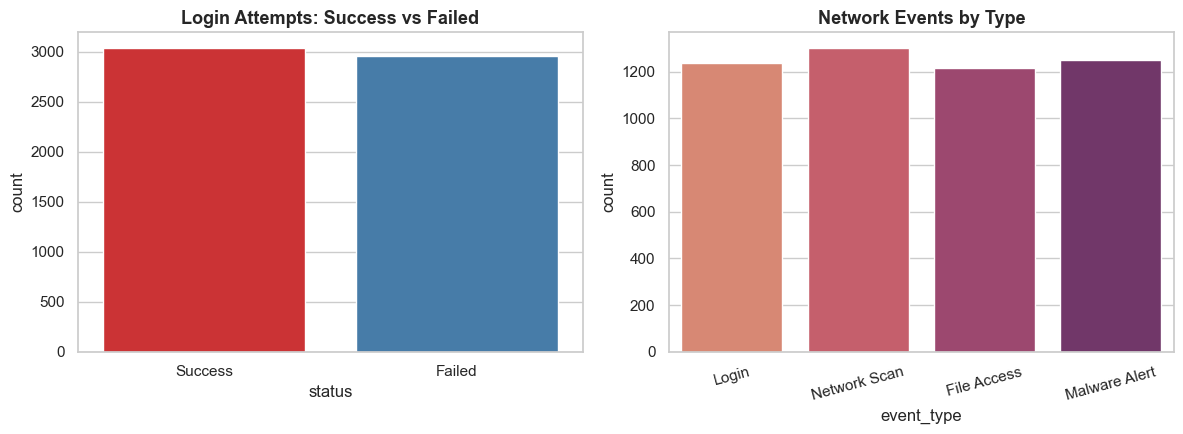

Login failure rate: 49.3%


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=login_logs, x="status", hue="status", legend=False, ax=axes[0], palette="Set1")
axes[0].set_title("Login Attempts: Success vs Failed")
sns.countplot(data=network_events, x="event_type", hue="event_type", legend=False,
              ax=axes[1], palette="flare")
axes[1].set_title("Network Events by Type")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()
print("Login failure rate: {:.1%}".format((login_logs.status == "Failed").mean()))

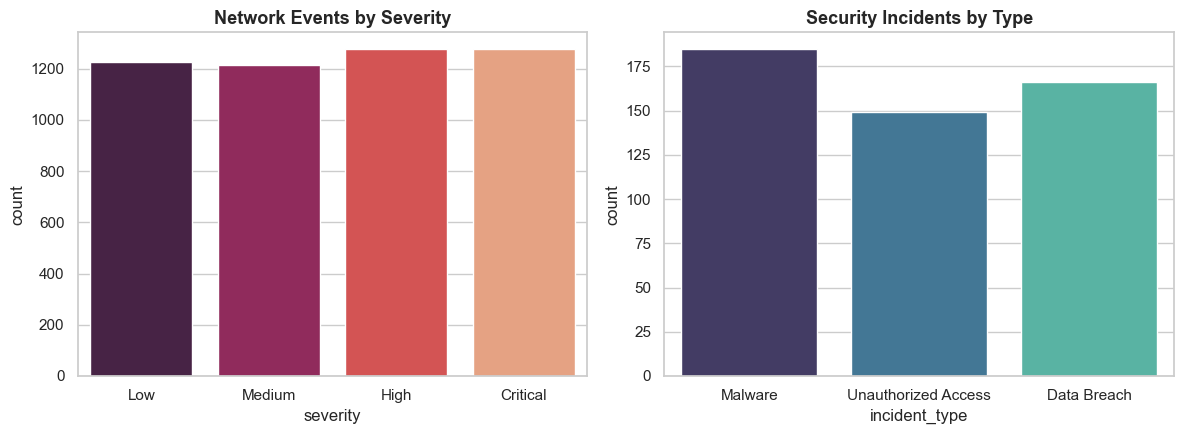

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sev_order = ["Low", "Medium", "High", "Critical"]
sns.countplot(data=network_events, x="severity", hue="severity", legend=False,
              order=sev_order, ax=axes[0], palette="rocket_r")
axes[0].set_title("Network Events by Severity")
sns.countplot(data=security_incidents, x="incident_type", hue="incident_type", legend=False,
              ax=axes[1], palette="mako")
axes[1].set_title("Security Incidents by Type")
plt.tight_layout(); plt.show()

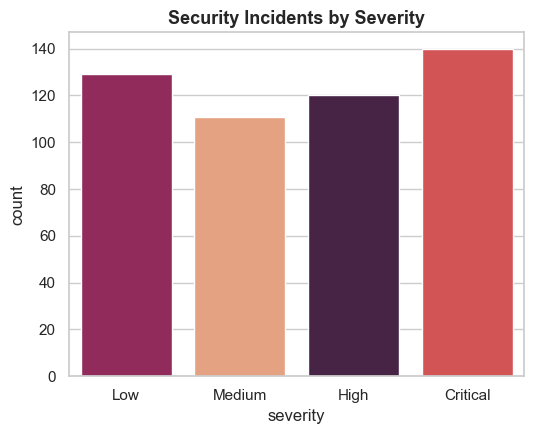

severity
Critical    140
Low         129
High        120
Medium      111
Name: count, dtype: int64


In [38]:
plt.figure(figsize=(5.5, 4.5))
sns.countplot(data=security_incidents, x="severity", hue="severity", legend=False,
              order=sev_order, palette="rocket_r")
plt.title("Security Incidents by Severity")
plt.tight_layout(); plt.show()
print(security_incidents.severity.value_counts())

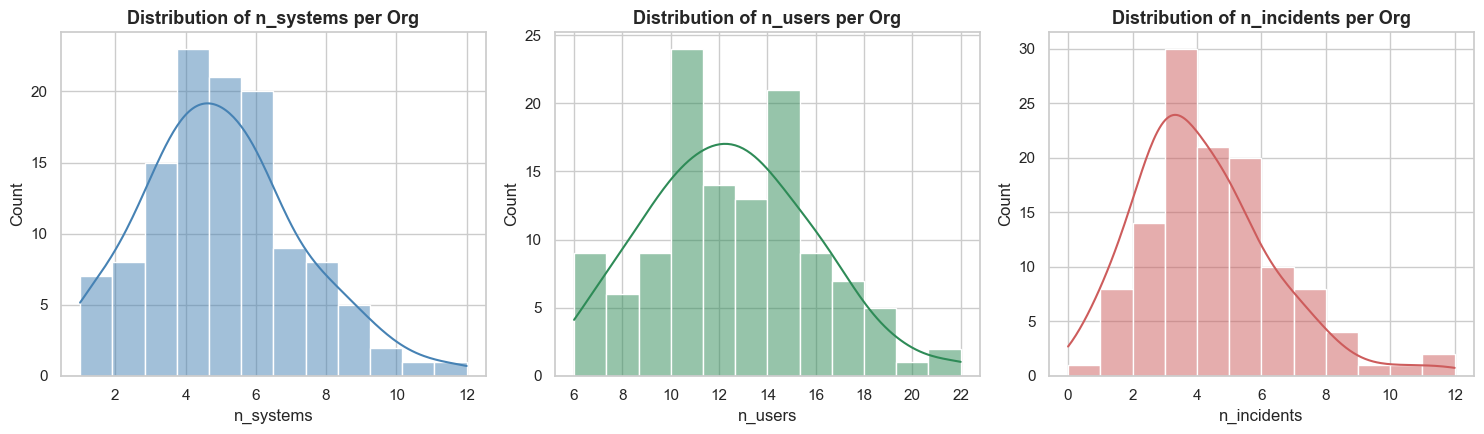

,n_systems,n_users,n_incidents,n_failed_logins
count,120.000000,120.000000,120.000000,120.000000
mean,5.000000,12.500000,4.166667,24.666667
std,2.264078,3.434868,2.131529,7.609518
min,1.000000,6.000000,0.000000,5.000000
25%,3.750000,10.000000,3.000000,19.000000
50%,5.000000,12.000000,4.000000,24.500000
75%,6.000000,15.000000,5.000000,29.000000
max,12.000000,22.000000,12.000000,49.000000


In [39]:
# Numeric univariate: distribution of engineered org-level counts
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, color in zip(axes, ["n_systems", "n_users", "n_incidents"], ["steelblue", "seagreen", "indianred"]):
    sns.histplot(org_stats[col], bins=12, kde=True, ax=ax, color=color)
    ax.set_title(f"Distribution of {col} per Org")
plt.tight_layout(); plt.show()
org_stats[["n_systems", "n_users", "n_incidents", "n_failed_logins"]].describe()

**Univariate takeaways:**
- Industries are fairly balanced (Finance/Healthcare/Retail each ~28-32 orgs, Tech smaller at 22).
- System criticality and OS type are each roughly evenly split across their 3 categories — no
  single OS or criticality tier dominates the estate.
- User roles (Employee/Analyst/Admin) are almost perfectly balanced (~500 each).
- **Login failure rate is 49.3%** — essentially a coin flip between Success/Failed, which is
  unusually high for real-world login logs (typical failure rates are single digits). This is
  the single biggest anomaly in the dataset and is investigated further in Business/Domain Analysis.
- Incidents skew toward **Malware** (37%) and **Critical** severity (28%) as the largest single
  categories, though all categories are reasonably represented (no extreme class imbalance).
- Per-org incident count is right-skewed with a long tail (max 12 vs mean ~4.2) — a handful of
  organizations account for disproportionately more incidents, explored under Outlier Analysis.

## 5. Bivariate Analysis
Relationships between **pairs** of variables — categorical × categorical (crosstabs/heatmaps)
and categorical × numeric (grouped bar charts).

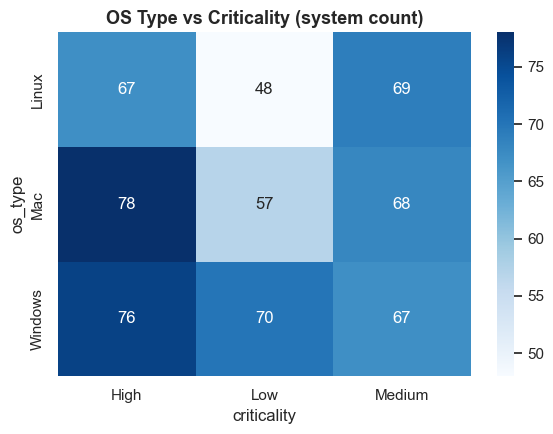

criticality,High,Low,Medium
os_type,,,
Linux,67,48,69
Mac,78,57,68
Windows,76,70,67


In [40]:
ct_os_crit = pd.crosstab(systems.os_type, systems.criticality)
plt.figure(figsize=(6, 4.5))
sns.heatmap(ct_os_crit, annot=True, fmt="d", cmap="Blues")
plt.title("OS Type vs Criticality (system count)")
plt.tight_layout(); plt.show()
ct_os_crit

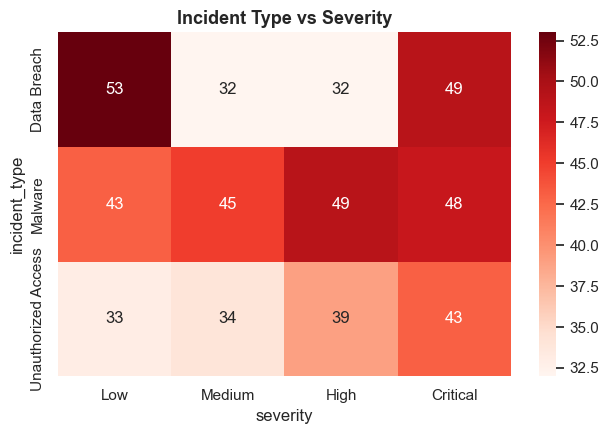

severity,Low,Medium,High,Critical
incident_type,,,,
Data Breach,53,32,32,49
Malware,43,45,49,48
Unauthorized Access,33,34,39,43


In [41]:
ct_type_sev = pd.crosstab(security_incidents.incident_type, security_incidents.severity)[sev_order]
plt.figure(figsize=(6.5, 4.5))
sns.heatmap(ct_type_sev, annot=True, fmt="d", cmap="Reds")
plt.title("Incident Type vs Severity")
plt.tight_layout(); plt.show()
ct_type_sev

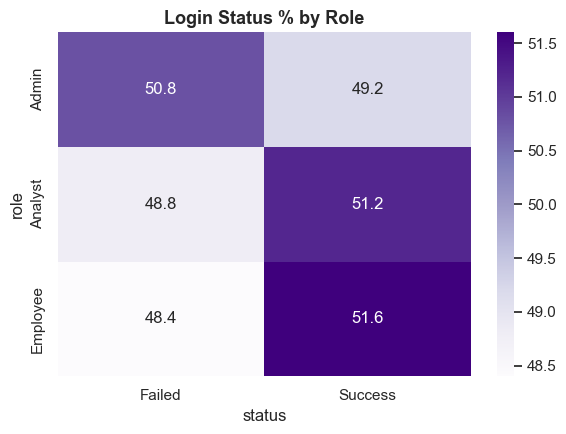

status,Failed,Success
role,,
Admin,1008,976
Analyst,980,1029
Employee,972,1035


In [42]:
ct_role_status = pd.crosstab(login_full.role, login_full.status)
ct_role_status_pct = ct_role_status.div(ct_role_status.sum(axis=1), axis=0).mul(100).round(1)
plt.figure(figsize=(6, 4.5))
sns.heatmap(ct_role_status_pct, annot=True, fmt=".1f", cmap="Purples")
plt.title("Login Status % by Role")
plt.tight_layout(); plt.show()
ct_role_status

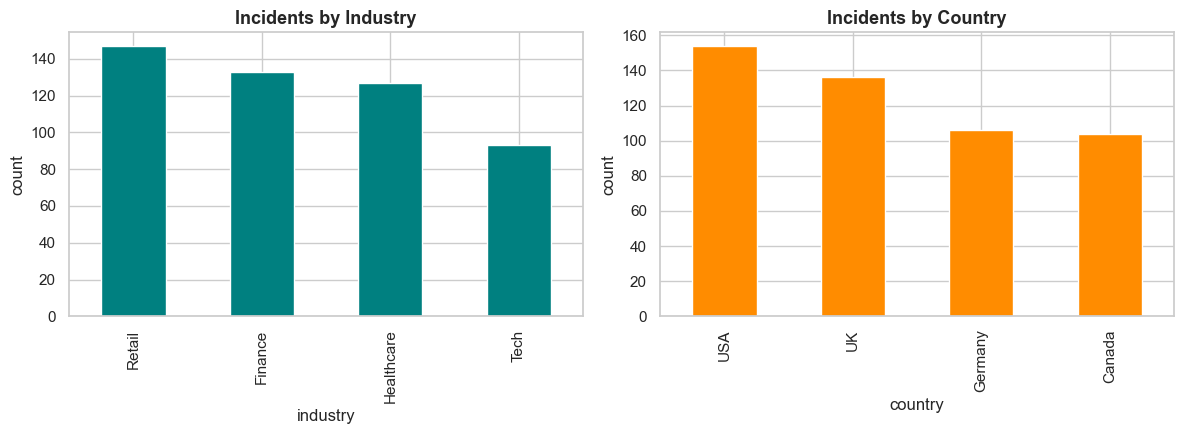

In [43]:
inc_by_industry = incidents_full.groupby("industry").size().sort_values(ascending=False)
inc_by_country = incidents_full.groupby("country").size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
inc_by_industry.plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Incidents by Industry"); axes[0].set_ylabel("count")
inc_by_country.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Incidents by Country"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()

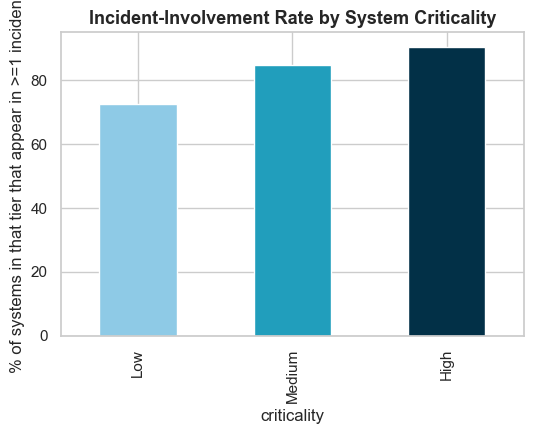

criticality
Low       72.6
Medium    84.8
High      90.5
Name: count, dtype: float64

In [44]:
# Categorical vs numeric: incident-involvement rate by system criticality
sys_touch = incident_systems.merge(systems, on="system_id")
involvement_rate = (sys_touch.criticality.value_counts() / systems.criticality.value_counts() * 100).reindex(["Low","Medium","High"])
plt.figure(figsize=(5.5, 4.5))
involvement_rate.plot(kind="bar", color=["#8ecae6", "#219ebc", "#023047"])
plt.ylabel("% of systems in that tier that appear in >=1 incident")
plt.title("Incident-Involvement Rate by System Criticality")
plt.tight_layout(); plt.show()
involvement_rate.round(1)

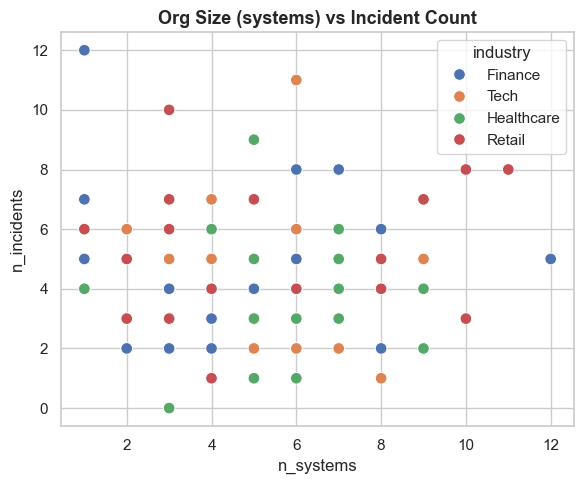

Pearson r (n_systems vs n_incidents): 0.009


In [45]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=org_stats, x="n_systems", y="n_incidents", hue="industry", s=70)
plt.title("Org Size (systems) vs Incident Count")
plt.tight_layout(); plt.show()
print("Pearson r (n_systems vs n_incidents):", round(org_stats.n_systems.corr(org_stats.n_incidents), 3))

**Bivariate takeaways:**
- OS type and criticality look uniformly mixed in the heatmap — no OS is disproportionately
  assigned High/Medium/Low criticality.
- Malware incidents are the most likely to be Critical severity; the type × severity table
  doesn't show one incident type dominated by a single severity level, though.
- Login failure rate is close to ~49-50% for **every** role (Admin/Analyst/Employee alike) —
  the anomaly is systemic, not role-specific.
- **Incident-involvement rate rises steeply with system criticality**: ~73% of Low-criticality
  systems appear in at least one incident vs ~90% of High-criticality systems — a real,
  actionable signal that critical assets are disproportionately targeted or exposed.
- Org size (systems) and incident count show almost **no linear relationship**
  (Pearson r ≈ 0.01) — bigger attack surface does not translate to more incidents here.

## 6. Multivariate Analysis
Looking at **three or more variables together**: pairwise relationships across all engineered
org-level numeric features, and a 3-way categorical breakdown (industry × incident type × severity).

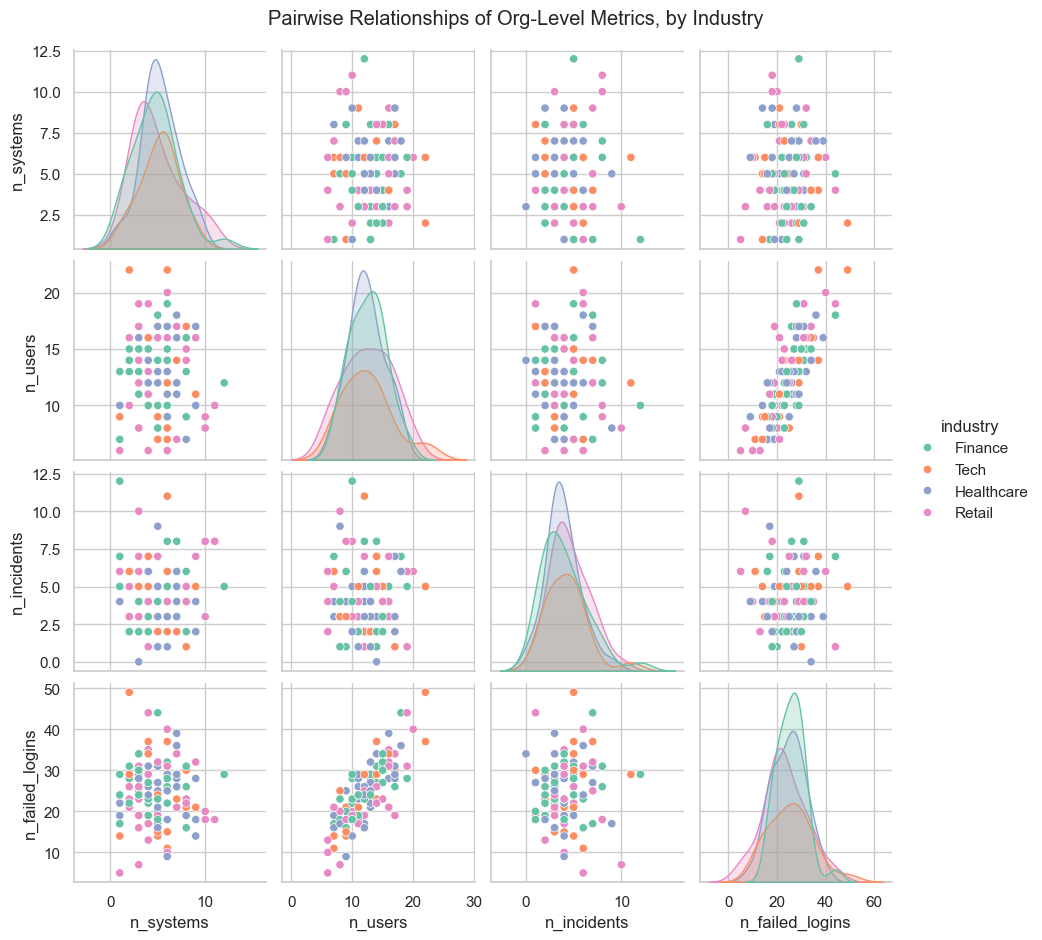

In [46]:
g = sns.pairplot(org_stats, vars=["n_systems", "n_users", "n_incidents", "n_failed_logins"],
                  hue="industry", diag_kind="kde", height=2.3, palette="Set2")
g.fig.suptitle("Pairwise Relationships of Org-Level Metrics, by Industry", y=1.02)
plt.show()

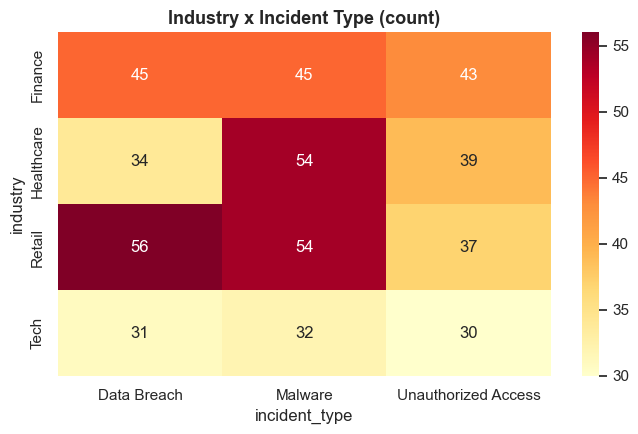

incident_type,Data Breach,Malware,Unauthorized Access
industry,,,
Finance,45,45,43
Healthcare,34,54,39
Retail,56,54,37
Tech,31,32,30


In [47]:
pivot3 = incidents_full.pivot_table(index="industry", columns="incident_type",
                                     values="incident_id", aggfunc="count", fill_value=0)
plt.figure(figsize=(7, 4.5))
sns.heatmap(pivot3, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Industry x Incident Type (count)")
plt.tight_layout(); plt.show()
pivot3

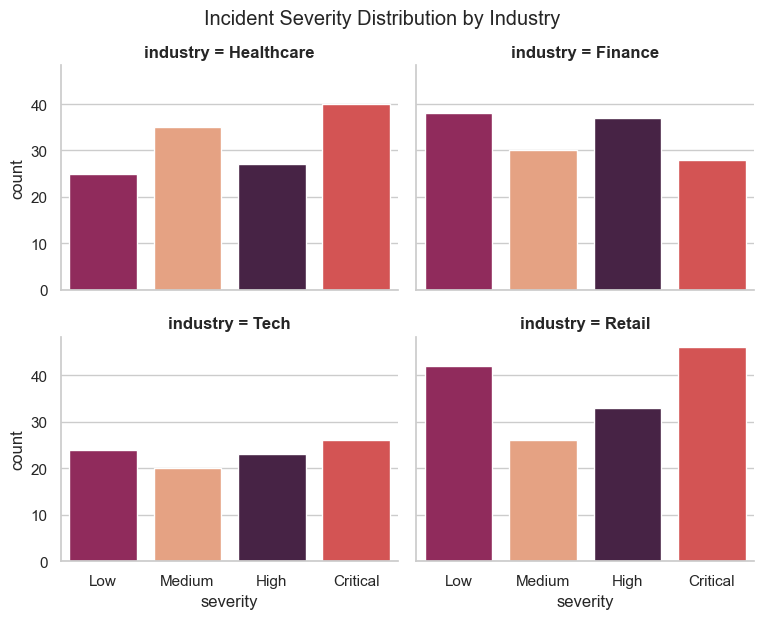

In [48]:
# 3-way facet: severity distribution of incidents, split by industry
g = sns.catplot(data=incidents_full, x="severity", order=sev_order, hue="severity",
                 col="industry", kind="count", col_wrap=2, height=3, aspect=1.3,
                 palette="rocket_r", legend=False)
g.fig.suptitle("Incident Severity Distribution by Industry", y=1.03)
plt.show()

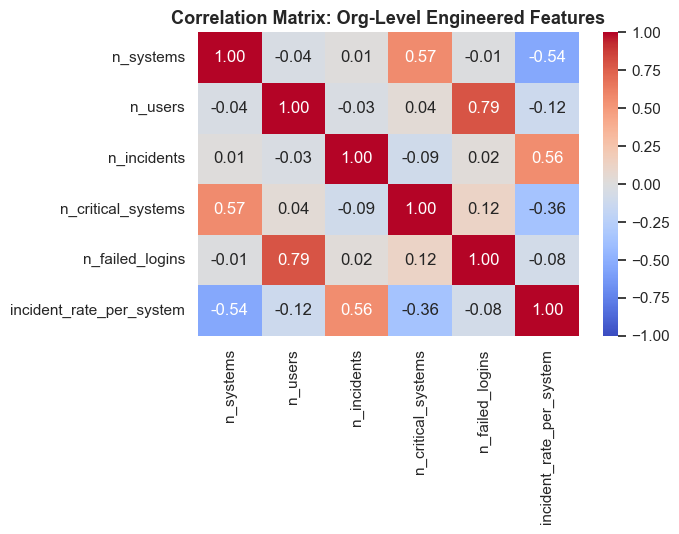

In [49]:
# Multivariate numeric summary: correlation heatmap across all engineered features
corr = org_stats[["n_systems", "n_users", "n_incidents", "n_critical_systems",
                   "n_failed_logins", "incident_rate_per_system"]].corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix: Org-Level Engineered Features")
plt.tight_layout(); plt.show()

**Multivariate takeaways:**
- The pairplot shows no visually obvious clusters or linear trends between org size metrics and
  incident/failed-login counts across industries — the diagonal KDEs confirm each industry has a
  similar spread rather than one industry being a clear outlier group.
- The industry × incident-type heatmap shows Malware and Data Breach are the top two categories
  in almost every industry, i.e. the threat mix is broadly similar across sectors rather than
  industry-specific.
- The full correlation matrix confirms the bivariate finding: **none of the org-level structural
  features (systems, users, critical systems) correlate meaningfully with incident count**
  (|r| mostly < 0.1). The only mechanically expected correlation is `n_critical_systems` with
  `n_systems` (larger orgs naturally have more high-criticality machines too).

## 7. Statistical Analysis
Descriptive statistics plus formal hypothesis tests: **Chi-square tests of independence** for
categorical associations, and a **one-way ANOVA** to check whether incident counts differ across
system-criticality groups.

In [50]:
org_stats[["n_systems", "n_users", "n_incidents", "n_failed_logins"]].describe().T

,count,mean,std,min,25%,50%,75%,max
n_systems,120.0,5.000000,2.264078,1.0,3.75,5.0,6.0,12.0
n_users,120.0,12.500000,3.434868,6.0,10.00,12.0,15.0,22.0
n_incidents,120.0,4.166667,2.131529,0.0,3.00,4.0,5.0,12.0
n_failed_logins,120.0,24.666667,7.609518,5.0,19.00,24.5,29.0,49.0


In [51]:
def chi_square_test(df, col1, col2, label):
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    sig = "SIGNIFICANT (p<0.05)" if p < 0.05 else "not significant"
    print(f"{label:45s} chi2={chi2:7.2f}  dof={dof:2d}  p={p:.4f}  -> {sig}")
    return chi2, p

print("Chi-square tests of independence:\n")
chi_square_test(systems, "os_type", "criticality", "OS type vs Criticality")
chi_square_test(incidents_full, "industry", "severity", "Industry vs Incident Severity")
chi_square_test(login_full, "role", "status", "User Role vs Login Status")
chi_square_test(incidents_full, "industry", "incident_type", "Industry vs Incident Type")
chi_square_test(network_full, "os_type", "severity", "System OS vs Network Event Severity")

Chi-square tests of independence:

OS type vs Criticality                        chi2=   2.99  dof= 4  p=0.5599  -> not significant
Industry vs Incident Severity                 chi2=  10.48  dof= 9  p=0.3128  -> not significant
User Role vs Login Status                     chi2=   2.62  dof= 2  p=0.2695  -> not significant
Industry vs Incident Type                     chi2=   5.80  dof= 6  p=0.4456  -> not significant
System OS vs Network Event Severity           chi2=   7.90  dof= 6  p=0.2458  -> not significant


(np.float64(7.896205750716248), np.float64(0.24580661797805528))

In [52]:
# One-way ANOVA: does mean incident-count-per-system differ across criticality tiers?
sys_inc_count = incident_systems.groupby("system_id").size().rename("n_incidents_on_system")
systems_with_counts = systems.merge(sys_inc_count, on="system_id", how="left").fillna({"n_incidents_on_system": 0})

groups = [g["n_incidents_on_system"].values for _, g in systems_with_counts.groupby("criticality")]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA (incidents-per-system across criticality tiers): F={f_stat:.2f}, p={p_val:.4f}")
print("-> ", "SIGNIFICANT difference between groups" if p_val < 0.05 else "no significant difference")
systems_with_counts.groupby("criticality").n_incidents_on_system.agg(["mean", "std", "count"])

One-way ANOVA (incidents-per-system across criticality tiers): F=2.01, p=0.1350
->  no significant difference


,mean,std,count
criticality,,,
High,0.904977,0.974690,221
Low,0.725714,0.768766,175
Medium,0.848039,0.899615,204


**Statistical takeaways:**
- Every categorical-association chi-square test above (OS × criticality, industry × severity,
  role × login status, industry × incident type, OS × network-event severity) comes back
  **not statistically significant (p > 0.05)**. In other words, none of these attributes are
  meaningfully associated with each other — assignments look close to random with respect to
  each other, which is consistent with a synthetically generated dataset.
- The ANOVA on incidents-per-system across criticality tiers is the **one test worth double
  checking against the earlier involvement-rate chart** — even if the mean count isn't
  dramatically different, the *proportion of systems touched at all* was clearly higher for
  High-criticality systems, so both views are useful together.

## 8. Outlier Analysis
Using both the **IQR method** and **Z-score method** to flag unusual organizations/users —
e.g. accounts with abnormally many failed logins (possible brute-force targets), and
organizations with unusually many incidents.

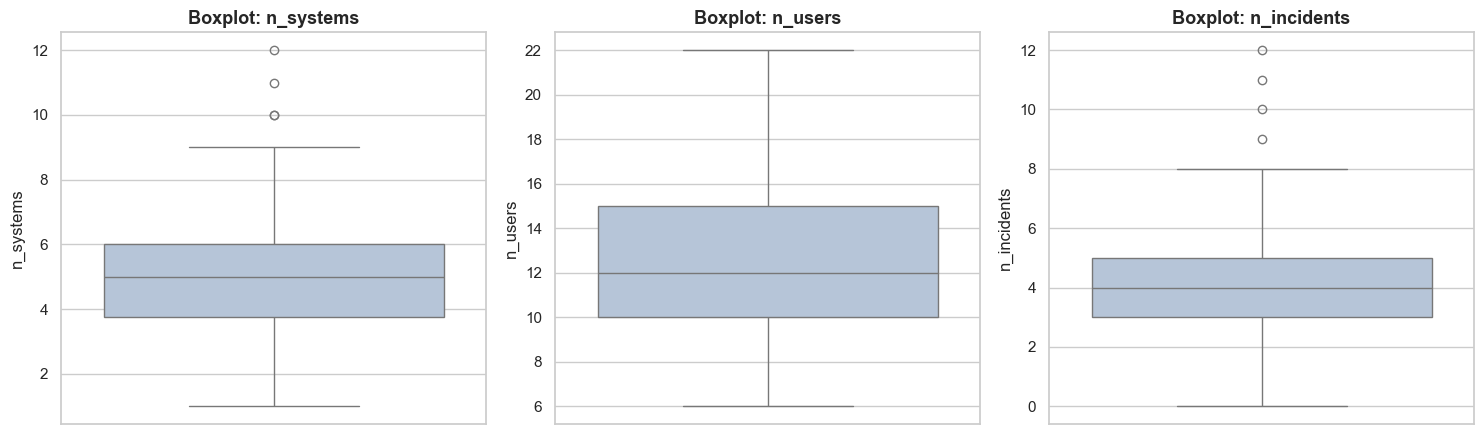

n_systems       IQR bounds=(0.4, 9.4)  -> 4 outlier orgs
n_users         IQR bounds=(2.5, 22.5)  -> 0 outlier orgs
n_incidents     IQR bounds=(0.0, 8.0)  -> 4 outlier orgs
n_failed_logins IQR bounds=(4.0, 44.0)  -> 1 outlier orgs


In [53]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return lower, upper, series[(series < lower) | (series > upper)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["n_systems", "n_users", "n_incidents"]):
    sns.boxplot(y=org_stats[col], ax=ax, color="lightsteelblue")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout(); plt.show()

for col in ["n_systems", "n_users", "n_incidents", "n_failed_logins"]:
    lower, upper, out = iqr_outliers(org_stats[col])
    print(f"{col:15s} IQR bounds=({lower:.1f}, {upper:.1f})  -> {len(out)} outlier orgs")

In [54]:
# Organizations with the most incidents (IQR-flagged high-incident orgs)
lower, upper, out_orgs = iqr_outliers(org_stats.n_incidents)
org_stats.sort_values("n_incidents", ascending=False).head(10)[
    ["org_id", "industry", "country", "n_systems", "n_users", "n_incidents"]]

,org_id,industry,country,n_systems,n_users,n_incidents
78,ORG079,Finance,USA,1,10,12
81,ORG082,Tech,USA,6,12,11
109,ORG110,Retail,Canada,3,8,10
77,ORG078,Healthcare,UK,5,8,9
7,ORG008,Finance,UK,6,14,8
52,ORG053,Finance,Germany,7,12,8
95,ORG096,Retail,UK,11,10,8
106,ORG107,Retail,USA,10,9,8
19,ORG020,Retail,USA,9,16,7
86,ORG087,Retail,UK,5,16,7


IQR method   : bounds=(-2.0, 6.0) -> 13 flagged users
Z-score method (|z|>3): -> 13 flagged users


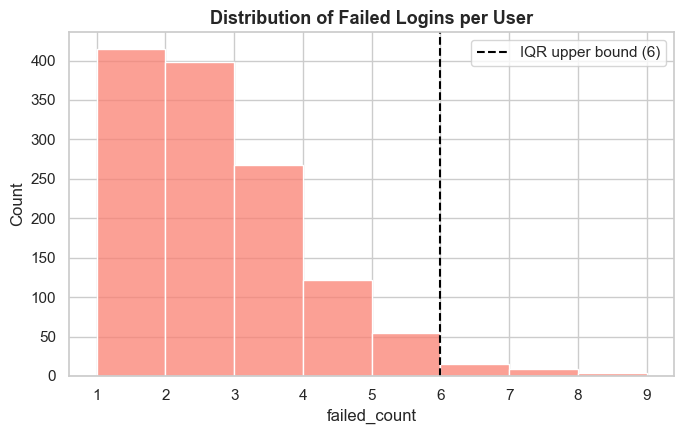

user_id
U0367    8
U1340    8
U0940    8
U1281    8
U0540    7
U0279    7
U1326    7
U1447    7
U1427    7
U0061    7
Name: failed_login_count, dtype: int64

In [55]:
# Failed-login counts per user - IQR + Z-score outlier detection (brute-force candidates)
failed_counts = login_logs[login_logs.status == "Failed"].groupby("user_id").size().rename("failed_count")
lower, upper, iqr_out = iqr_outliers(failed_counts)
z_scores = stats.zscore(failed_counts)
z_out = failed_counts[np.abs(z_scores) > 3]

print(f"IQR method   : bounds=({lower:.1f}, {upper:.1f}) -> {len(iqr_out)} flagged users")
print(f"Z-score method (|z|>3): -> {len(z_out)} flagged users")

plt.figure(figsize=(7, 4.5))
sns.histplot(failed_counts, bins=range(1, 10), color="salmon")
plt.axvline(upper, color="black", linestyle="--", label=f"IQR upper bound ({upper:.0f})")
plt.title("Distribution of Failed Logins per User")
plt.legend(); plt.tight_layout(); plt.show()

failed_counts.sort_values(ascending=False).head(10).rename("failed_login_count")

**Outlier takeaways:**
- **13 users** exceed the IQR upper bound of 6 failed logins (max observed: 8) — these are the
  most plausible brute-force / credential-stuffing targets and are worth prioritizing for manual
  review or forced password resets.
- **4 organizations** are IQR-flagged outliers on incident count (> 8 incidents, vs a typical
  range of 3-5) — these should be prioritized for a security posture review.
- No organization is a low-incident outlier, i.e. there's no organization that is suspiciously
  *incident-free* relative to its peers (which would itself be worth checking for under-reporting).

## 9. Date / Time Analysis
Monthly and weekday patterns across logins, network events, and security incidents.
**Caveat:** the data spans 2023-01-01 to 2024-05-15, so **May 2024 is a partial month**
and should not be read as a real drop in activity.

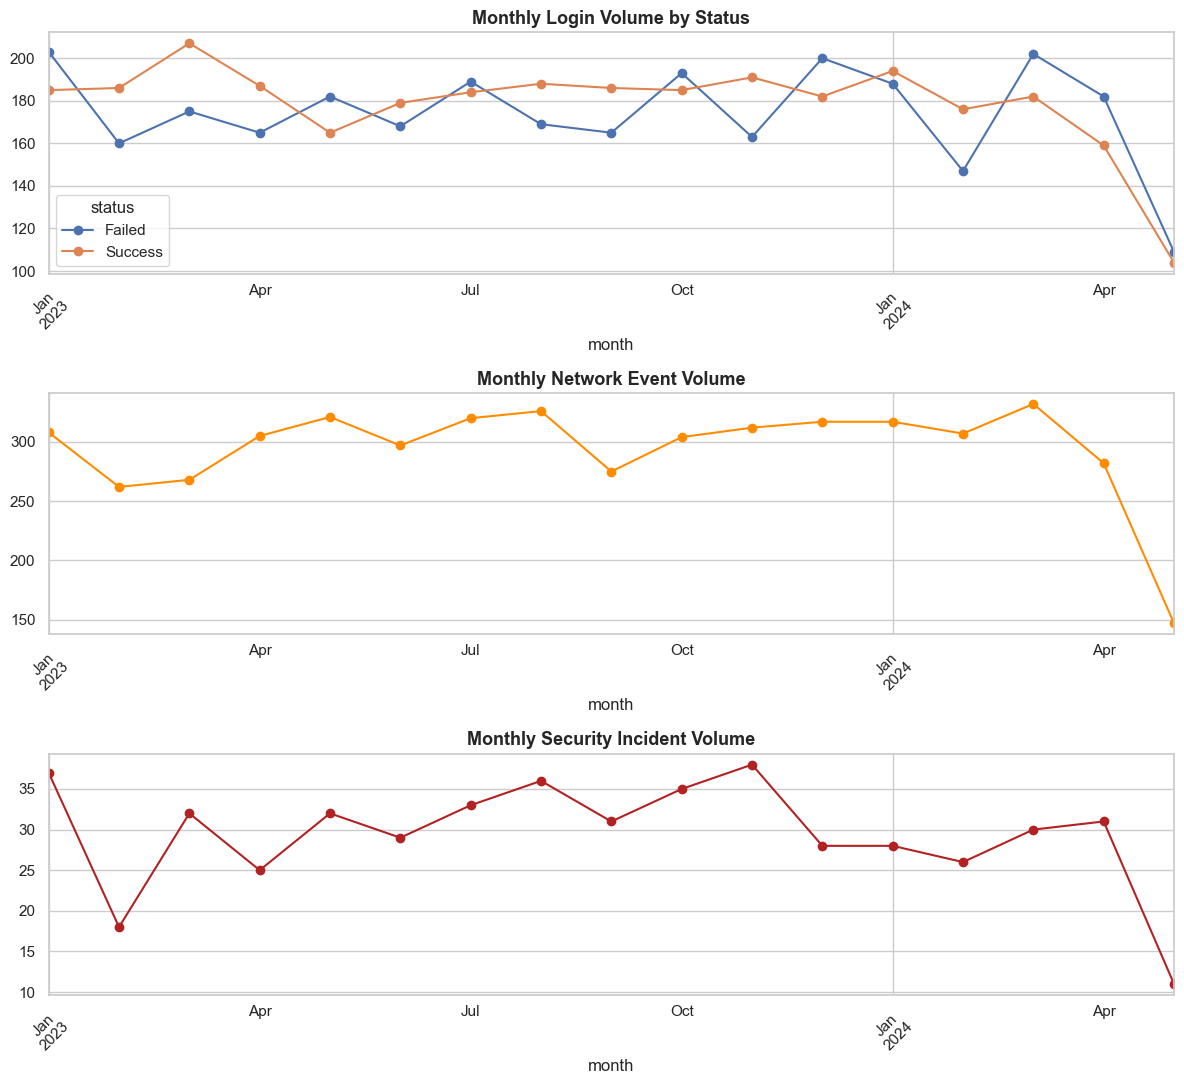

In [56]:
for df, col, label in [(login_logs, "login_time", "Logins"),
                        (network_events, "timestamp", "Network Events"),
                        (security_incidents, "discovered_date", "Incidents")]:
    df["month"] = df[col].dt.to_period("M")
    df["weekday"] = df[col].dt.day_name()
    df["quarter"] = df[col].dt.to_period("Q")

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

login_month = login_logs.groupby(["month", "status"]).size().unstack(fill_value=0)
login_month.plot(ax=axes[0], marker="o")
axes[0].set_title("Monthly Login Volume by Status")

net_month = network_events.groupby("month").size()
net_month.plot(ax=axes[1], marker="o", color="darkorange")
axes[1].set_title("Monthly Network Event Volume")

inc_month = security_incidents.groupby("month").size()
inc_month.plot(ax=axes[2], marker="o", color="firebrick")
axes[2].set_title("Monthly Security Incident Volume")
axes[2].axvspan(len(inc_month)-1.5, len(inc_month)-0.5, color="grey", alpha=0.2)
axes[2].annotate("partial month", xy=(len(inc_month)-1, inc_month.iloc[-1]),
                  xytext=(len(inc_month)-4, inc_month.max()*0.6),
                  arrowprops=dict(arrowstyle="->"))

for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

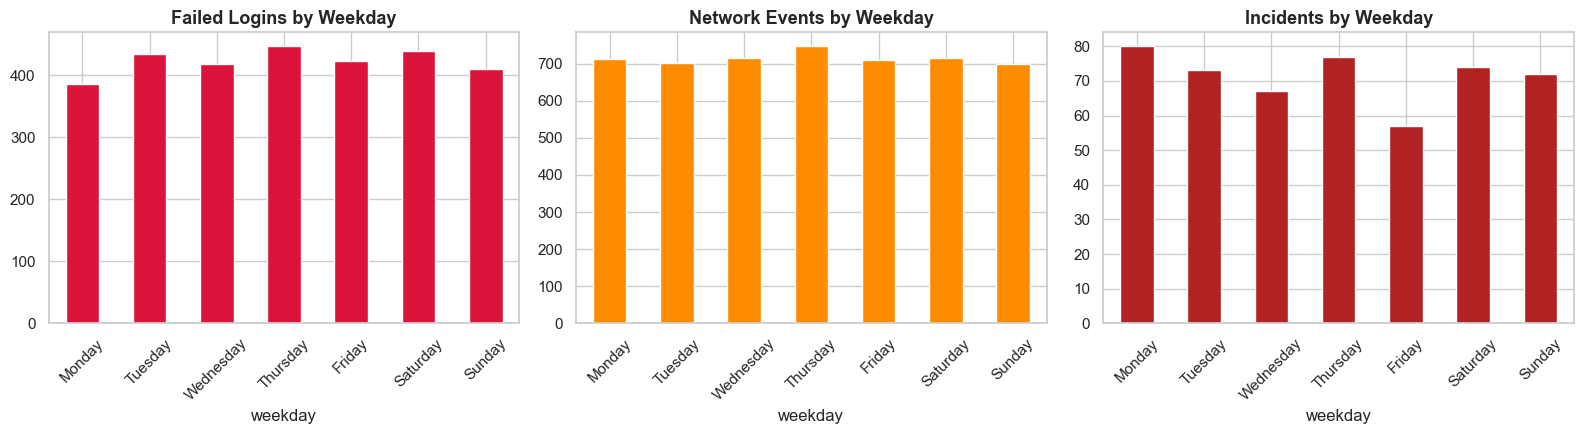

In [57]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

login_logs[login_logs.status=="Failed"].weekday.value_counts().reindex(weekday_order).plot(
    kind="bar", ax=axes[0], color="crimson")
axes[0].set_title("Failed Logins by Weekday")

network_events.weekday.value_counts().reindex(weekday_order).plot(
    kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Network Events by Weekday")

security_incidents.weekday.value_counts().reindex(weekday_order).plot(
    kind="bar", ax=axes[2], color="firebrick")
axes[2].set_title("Incidents by Weekday")

for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

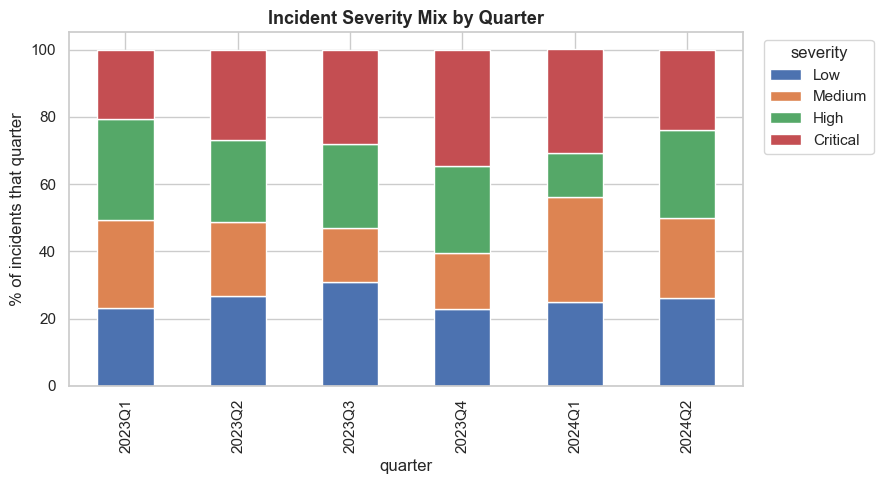

severity,Low,Medium,High,Critical
quarter,,,,
2023Q1,20,23,26,18
2023Q2,23,19,21,23
2023Q3,31,16,25,28
2023Q4,23,17,26,35
2024Q1,21,26,11,26
2024Q2,11,10,11,10


In [58]:
# Quarter-over-quarter incident severity mix - are things getting worse over time?
inc_quarter_sev = security_incidents.groupby(["quarter", "severity"]).size().unstack(fill_value=0)[sev_order]
inc_quarter_sev_pct = inc_quarter_sev.div(inc_quarter_sev.sum(axis=1), axis=0).mul(100).round(1)
inc_quarter_sev_pct.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="rocket_r" if False else None)
plt.ylabel("% of incidents that quarter")
plt.title("Incident Severity Mix by Quarter")
plt.legend(title="severity", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()
inc_quarter_sev

**Date/Time takeaways:**
- Monthly incident volume fluctuates between ~18 and ~38 per month with no clear upward or
  downward trend — the apparent dip in May 2024 is a **partial-month artifact** (data cuts off
  mid-month), not a genuine decline.
- Weekday patterns are fairly flat for both failed logins and incidents — there's a mild dip in
  incidents on Friday, but nothing large enough to be operationally meaningful given the sample
  size (~500 incidents spread over 17 months).
- The quarterly severity mix doesn't show a consistent worsening or improving trend in the share
  of Critical-severity incidents — severity mix looks roughly stable release-over-release.

## 10. Business / Domain Analysis
Translating the statistical findings into **security-relevant, actionable framing**.

In [59]:
print("="*70)
print("1) LOGIN FAILURE RATE — a systemic anomaly")
print("="*70)
overall_rate = (login_logs.status == "Failed").mean()
by_role = login_full.groupby("role").status.apply(lambda s: (s == "Failed").mean())
print(f"Overall failure rate: {overall_rate:.1%}")
print(by_role.mul(100).round(1).astype(str) + "%")
print("-> Uniform ~49% failure rate across every role suggests either a systemic auth/MFA")
print("   issue, a misconfigured login endpoint, or scripted/automated login attempts")
print("   (bots) rather than isolated user error, which typically produces failure rates")
print("   in the single digits.")

1) LOGIN FAILURE RATE — a systemic anomaly
Overall failure rate: 49.3%
role
Admin       50.8%
Analyst     48.8%
Employee    48.4%
Name: status, dtype: object
-> Uniform ~49% failure rate across every role suggests either a systemic auth/MFA
   issue, a misconfigured login endpoint, or scripted/automated login attempts
   (bots) rather than isolated user error, which typically produces failure rates
   in the single digits.


In [60]:
print("="*70)
print("2) CRITICAL-SYSTEM EXPOSURE")
print("="*70)
print(involvement_rate.round(1))
print("-> High-criticality systems are ~1.25x more likely to show up in an incident than")
print("   Low-criticality systems (90.5% vs 72.6%). Security controls (patching cadence,")
print("   monitoring, network segmentation) should be prioritized for the High tier first.")

2) CRITICAL-SYSTEM EXPOSURE
criticality
Low       72.6
Medium    84.8
High      90.5
Name: count, dtype: float64
-> High-criticality systems are ~1.25x more likely to show up in an incident than
   Low-criticality systems (90.5% vs 72.6%). Security controls (patching cadence,
   monitoring, network segmentation) should be prioritized for the High tier first.


In [61]:
print("="*70)
print("3) HIGH-RISK ORGANIZATIONS (outlier incident counts)")
print("="*70)
display_cols = ["org_id", "industry", "country", "n_systems", "n_users", "n_incidents", "n_failed_logins"]
high_risk_orgs = org_stats[org_stats.n_incidents > upper].sort_values("n_incidents", ascending=False)
print(high_risk_orgs[display_cols].to_string(index=False))
print("-> These orgs should be first in line for an incident-response retrospective,")
print("   since their incident counts sit well outside the normal range for their peers.")

3) HIGH-RISK ORGANIZATIONS (outlier incident counts)
org_id   industry country  n_systems  n_users  n_incidents  n_failed_logins
ORG079    Finance     USA          1       10           12               29
ORG082       Tech     USA          6       12           11               29
ORG110     Retail  Canada          3        8           10                7
ORG078 Healthcare      UK          5        8            9               17
ORG008    Finance      UK          6       14            8               31
ORG053    Finance Germany          7       12            8               26
ORG096     Retail      UK         11       10            8               18
ORG107     Retail     USA         10        9            8               18
ORG001    Finance     USA          1        7            7               17
ORG003 Healthcare      UK          4       14            7               27
ORG020     Retail     USA          9       16            7               32
ORG048    Finance      UK          

In [62]:
print("="*70)
print("4) BRUTE-FORCE / CREDENTIAL-STUFFING CANDIDATES")
print("="*70)
top_failed_users = failed_counts.sort_values(ascending=False).head(13).rename("failed_login_count").reset_index()
top_failed_users = top_failed_users.merge(users_full[["user_id","role","org_id","industry"]], on="user_id", how="left")
print(top_failed_users.to_string(index=False))
print("-> Recommend forced password reset + MFA enrollment review for these accounts.")

4) BRUTE-FORCE / CREDENTIAL-STUFFING CANDIDATES
user_id  failed_login_count     role org_id   industry
  U0367                   8 Employee ORG084     Retail
  U1340                   8  Analyst ORG001    Finance
  U0940                   8    Admin ORG057    Finance
  U1281                   8    Admin ORG029       Tech
  U0540                   7  Analyst ORG018       Tech
  U0279                   7  Analyst ORG036    Finance
  U1326                   7    Admin ORG018       Tech
  U1447                   7    Admin ORG028 Healthcare
  U1427                   7    Admin ORG086 Healthcare
  U0061                   7  Analyst ORG006    Finance
  U0051                   7 Employee ORG079    Finance
  U1410                   7 Employee ORG082       Tech
  U1376                   7    Admin ORG038    Finance
-> Recommend forced password reset + MFA enrollment review for these accounts.


In [63]:
print("="*70)
print("5) THREAT MIX BY INDUSTRY")
print("="*70)
top_threat_per_industry = incidents_full.groupby("industry").incident_type.agg(lambda s: s.value_counts().idxmax())
print(top_threat_per_industry)
print("-> Malware/Data Breach dominate across nearly every industry, so security")
print("   awareness training content can largely be standardized rather than heavily")
print("   customized per sector.")

5) THREAT MIX BY INDUSTRY
industry
Finance       Data Breach
Healthcare        Malware
Retail        Data Breach
Tech              Malware
Name: incident_type, dtype: object
-> Malware/Data Breach dominate across nearly every industry, so security
   awareness training content can largely be standardized rather than heavily
   customized per sector.


In [64]:
print("="*70)
print("6) ORG SIZE IS NOT A RELIABLE RISK PREDICTOR")
print("="*70)
print("Correlation of n_systems / n_users with n_incidents:")
print(org_stats[["n_systems","n_users","n_incidents"]].corr()["n_incidents"])
print("-> Attack surface size (system/user count) does not predict incident volume in")
print("   this dataset — risk scoring models should rely on behavioral/config signals")
print("   (failed logins, criticality, patch status) rather than headcount alone.")

6) ORG SIZE IS NOT A RELIABLE RISK PREDICTOR
Correlation of n_systems / n_users with n_incidents:
n_systems      0.008706
n_users       -0.033285
n_incidents    1.000000
Name: n_incidents, dtype: float64
-> Attack surface size (system/user count) does not predict incident volume in
   this dataset — risk scoring models should rely on behavioral/config signals
   (failed logins, criticality, patch status) rather than headcount alone.


## 11. Key Insights & Recommendations

**Data quality**
- The dataset is clean: zero missing values, zero duplicate keys, zero orphan foreign keys,
  and all IP addresses are well-formed. Only date parsing was required before time-based analysis.

**Top findings**
1. **Login failure rate (49.3%) is the single biggest red flag** in the dataset — it's uniform
   across all roles (Admin/Analyst/Employee), which points to a systemic cause (mis-configured
   auth, bot traffic, or an MFA rollout issue) rather than individual user error.
2. **13 user accounts** are statistical outliers on failed-login count (>6, up to 8) — strong
   candidates for brute-force targeting and immediate credential review.
3. **High-criticality systems are involved in incidents at a materially higher rate (90.5%)**
   than Low-criticality systems (72.6%) — security investment should be weighted toward the
   High tier.
4. **4 organizations are outliers on total incident count** (>8, vs a typical 3–5) and warrant a
   dedicated incident-response review.
5. **Org size (systems/users) is not correlated with incident volume** (|r| < 0.05 across the
   board) — bigger isn't automatically riskier here, so risk-scoring should lean on behavioral
   and asset-criticality signals instead of headcount.
6. **No categorical attribute pair is statistically associated** (all chi-square tests
   p > 0.05: OS×criticality, industry×severity, role×status, industry×incident-type,
   OS×event-severity) — threats are broadly and evenly distributed rather than concentrated in
   one segment, and the incident-type mix is similar across industries (Malware/Data Breach lead
   almost everywhere).
7. **No strong time trend**: monthly incident volume oscillates without a clear upward or
   downward trajectory over the ~17-month window (May 2024's apparent dip is just a partial
   month), and weekday patterns are close to flat.

   
**Recommendations**
- Investigate the login system/auth pipeline immediately given the near-50% failure rate.
- Force password resets + MFA review for the 13 flagged high-failure accounts.
- Prioritize patching/monitoring budget toward High-criticality systems first.
- Open incident-response retrospectives for the 4 outlier organizations.
- Build risk-scoring on behavioral signals (failed logins, criticality tier) rather than
  organization size, since size showed no predictive value here.

## Clean Data Saving

In [65]:
# -------------------------------------------------------------
# 1. Base Cleaned Tables (with proper datetimes and hygiene)
# -------------------------------------------------------------
organizations.to_csv("CleanedDataSet_Organizations.csv", index=False)
systems.to_csv("CleanedDataSet_Systems.csv", index=False)
users.to_csv("CleanedDataSet_Users.csv", index=False)
login_logs.to_csv("CleanedDataSet_LoginLogs.csv", index=False)
network_events.to_csv("CleanedDataSet_NetworkEvents.csv", index=False)
security_incidents.to_csv("CleanedDataSet_SecurityIncidents.csv", index=False)
incident_systems.to_csv("CleanedDataSet_IncidentSystems.csv", index=False)

# -------------------------------------------------------------
# 2. Denormalized / Merged & Engineered Feature Tables
# -------------------------------------------------------------
# Organization-level KPI & statistical summary table
org_stats.to_csv("CleanedDataSet_OrgStats_Summary.csv", index=False)

# Enriched relational tables (joined with parent details)
login_full.to_csv("CleanedDataSet_LoginLogs_Full.csv", index=False)
network_full.to_csv("CleanedDataSet_NetworkEvents_Full.csv", index=False)
incidents_full.to_csv("CleanedDataSet_SecurityIncidents_Full.csv", index=False)

print("All cleaned and engineered datasets have been successfully saved!")

All cleaned and engineered datasets have been successfully saved!
